# Cadre

Ce notebook a pour objectif de sélectionner les données sur lesquelles porte le stage de Ruth. 

L’objectif est de travailler sur les données de capteurs grands fonds du réseau International Miscellaneous Stations, situés en mer Méditerranée, plus précisément dans le bassin du Levantin. Les deux réseaux de capteurs visés sont les réseaux CY30x (données d’hydrophones) et CY60x (données d’accéléromètres), situés au sud de l’île de Chypre.

Ces données sont en libre accès et directement interrogeables sur la plateforme EarthScope (anciennement IRIS). Pour plus d’informations sur les réseaux CY30x et CY60x, je vous invite à consulter la page dédiée : https://ds.iris.edu/mda/IM/.

L’objectif du stage est d’étudier les caractéristiques du bruit ambiant dans la zone.


In [1]:
# this will download 1 hour of data from a FR network station, and display a wafeform plot.
import os
import sys
import numpy as np
import pandas as pd
import scipy.io.wavfile as wavfile
import scipy.signal as sp 

from obspy import UTCDateTime
from obspy import read as obspy_read
from obspy import read_inventory as obspy_read_inventory
from obspy import Stream, Inventory
from obspy.clients.fdsn import Client

from pyproj import Geod
from scipy import signal
from matplotlib import pyplot as plt


sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")
from source.bruit_fm_manager import BruitfmManager

from publication.publication_figure import LargeFigure

### Get all stations available on bruit-fm

In [2]:
# available_clients = ["IRIS", "RESIF"]
available_clients = ["RESIF"]

networks = ["1B", "1E", "IM"]
root_csv_path = (
    r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\data\wav\bruit_fm\stations"
)
fpath_all_stations = os.path.join(root_csv_path, "bruit_fm_stations.csv")

use_client_id = 0

geod = Geod(ellps="WGS84")
# client = Client(available_clients[use_client_id])

# Flags
# parse_networks = True
scrap_all_stations = False
merge_all_stations = False
compute_elevation_diff_gebco = False

In [3]:
bruit_fm_manager = BruitfmManager(
    root_station_storage=root_csv_path, available_clients=available_clients
)

In [4]:
# if parse_networks:
# #     # Parse all network names from html file
#     bruit_fm_manager.parse_stations_from_html()
if scrap_all_stations:
    # Scrap all stations from selected networks
    bruit_fm_manager.scrap_networks_stations()
if merge_all_stations:
    # Merge all stations from selected networks
    bruit_fm_manager.merge_scraped_networks()
if compute_elevation_diff_gebco:
    # Compute elevation difference between stations and GEBOD topography
    bruit_fm_manager.compute_elevation_diff_gebco()

### Apply filter to get the stations matching requirements 

In [5]:
# Filter stations
required_channels = ["BDH", "EDH"]  # "Z", "BDH", "EDH",  "HHZ", "EHZ"
min_recording_duration = 7 * 24 * 60 * 60  # in seconds
max_distance_between_stations = 5  # in km -> corresponds to 100 x lambda for f = 50 Hz
selected_year = 2024
min_nb_rcv_by_array = 2  # Minimum number of receivers by array (grouped stations after distance selection)
min_depth = 0  # in meters -> to meet the deep water assumption

filtered_stations_fname = "hydro_on_seafloor"
filters = {
    "restricted_status": "open",
    "required_channels": required_channels,
    "min_recording_duration": min_recording_duration,
    "max_distance_between_stations": max_distance_between_stations,
    "selected_year": selected_year,
    "min_nb_rcv_by_array": min_nb_rcv_by_array,
    "min_depth": min_depth,
    "receiver_on_seafloor": True,
    "receiver_on_seafloor_tolerance": 50,
}
filtered_stations, _ = bruit_fm_manager.filter_stations(
    filters, save=True, verbose=False, filtered_stations_fname=filtered_stations_fname
)

================ Selected stations stats ================
Number of selected stations : 6
Number of networks : 1
Number of arrays (grouped stations) : 1
Number of stations in network IM : 6


c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\obspy\clients\fdsn\client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)
C:\Users\baptiste.menetrier\Desktop\devPy\phd\stage_Ruth\utils.py:226: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.savefig(fname, dpi=300)


Saved: C:\Users\baptiste.menetrier\Desktop\devPy\phd\stage_Ruth\img\station_map.png

--- IM.CY301..EDH ---
SPL: 166.2 dB re 1 µPa


c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\obspy\imaging\waveform.py:811: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  self.fig.subplots_adjust(hspace=0)
c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\obspy\imaging\waveform.py:296: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  self.fig.subplots_adjust(top=1.0 - fract_y, bottom=fract_y2,



--- IM.CY302..EDH ---
SPL: 131.1 dB re 1 µPa


c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\obspy\imaging\waveform.py:811: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  self.fig.subplots_adjust(hspace=0)
c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\obspy\imaging\waveform.py:296: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  self.fig.subplots_adjust(top=1.0 - fract_y, bottom=fract_y2,


...

c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\obspy\imaging\waveform.py:811: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  self.fig.subplots_adjust(hspace=0)
c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\obspy\imaging\waveform.py:296: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  self.fig.subplots_adjust(top=1.0 - fract_y, bottom=fract_y2,



--- IM.CY305..EDH ---
SPL: 130.8 dB re 1 µPa


c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\obspy\imaging\waveform.py:811: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  self.fig.subplots_adjust(hspace=0)
c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\obspy\imaging\waveform.py:296: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  self.fig.subplots_adjust(top=1.0 - fract_y, bottom=fract_y2,



--- IM.CY306..EDH ---
SPL: 130.0 dB re 1 µPa


c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\obspy\imaging\waveform.py:811: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  self.fig.subplots_adjust(hspace=0)
c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\obspy\imaging\waveform.py:296: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  self.fig.subplots_adjust(top=1.0 - fract_y, bottom=fract_y2,
c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


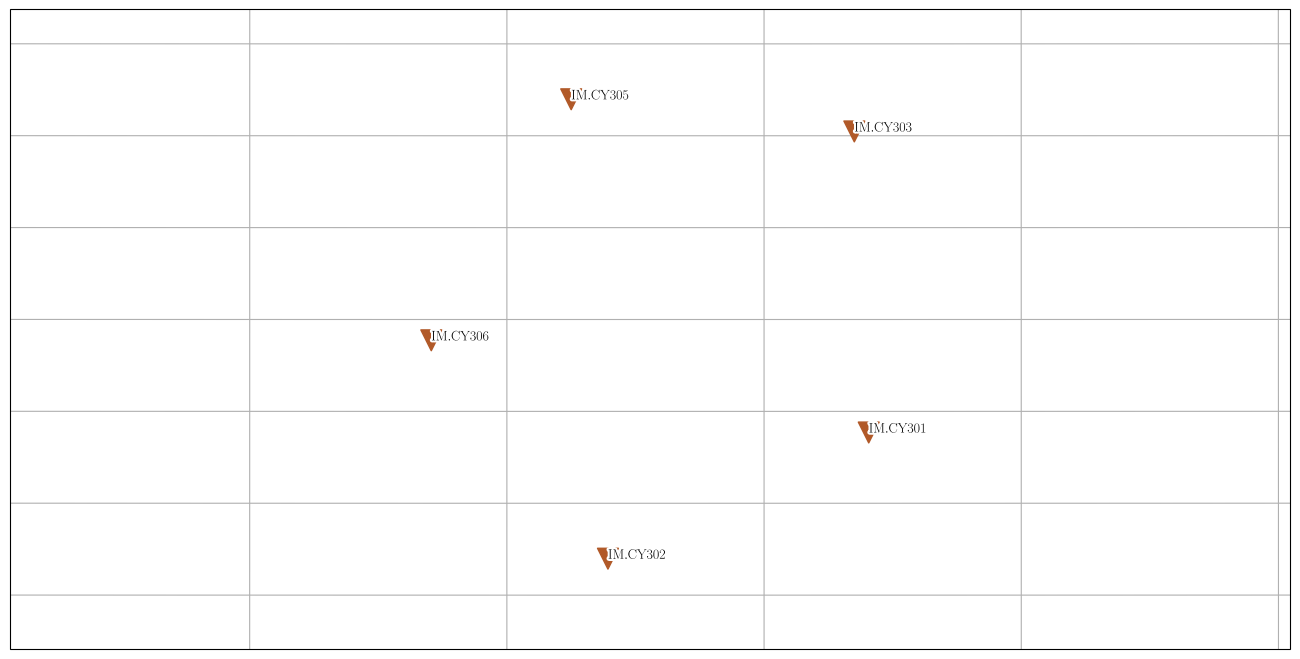

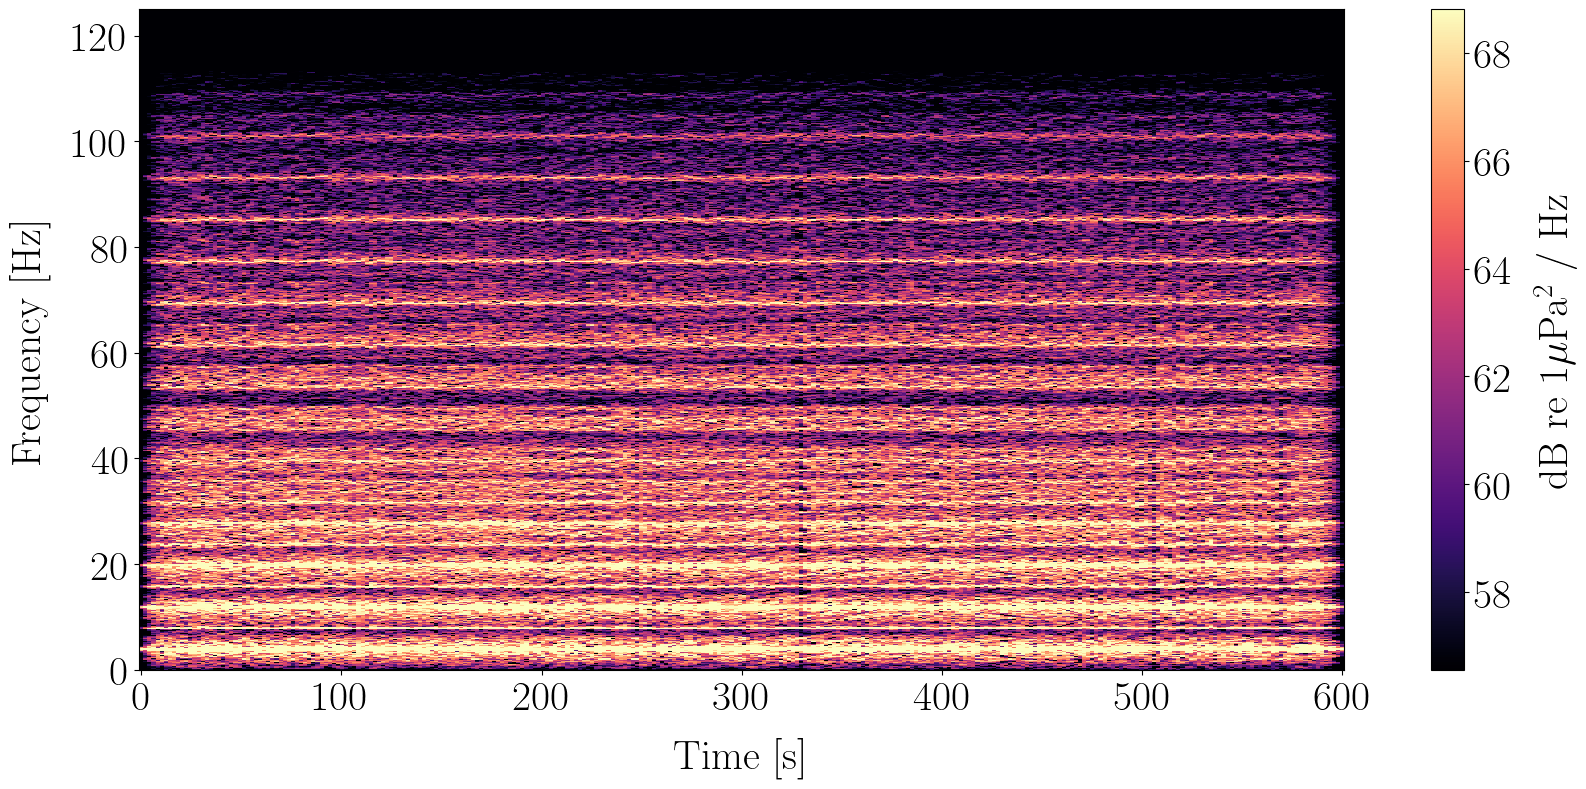

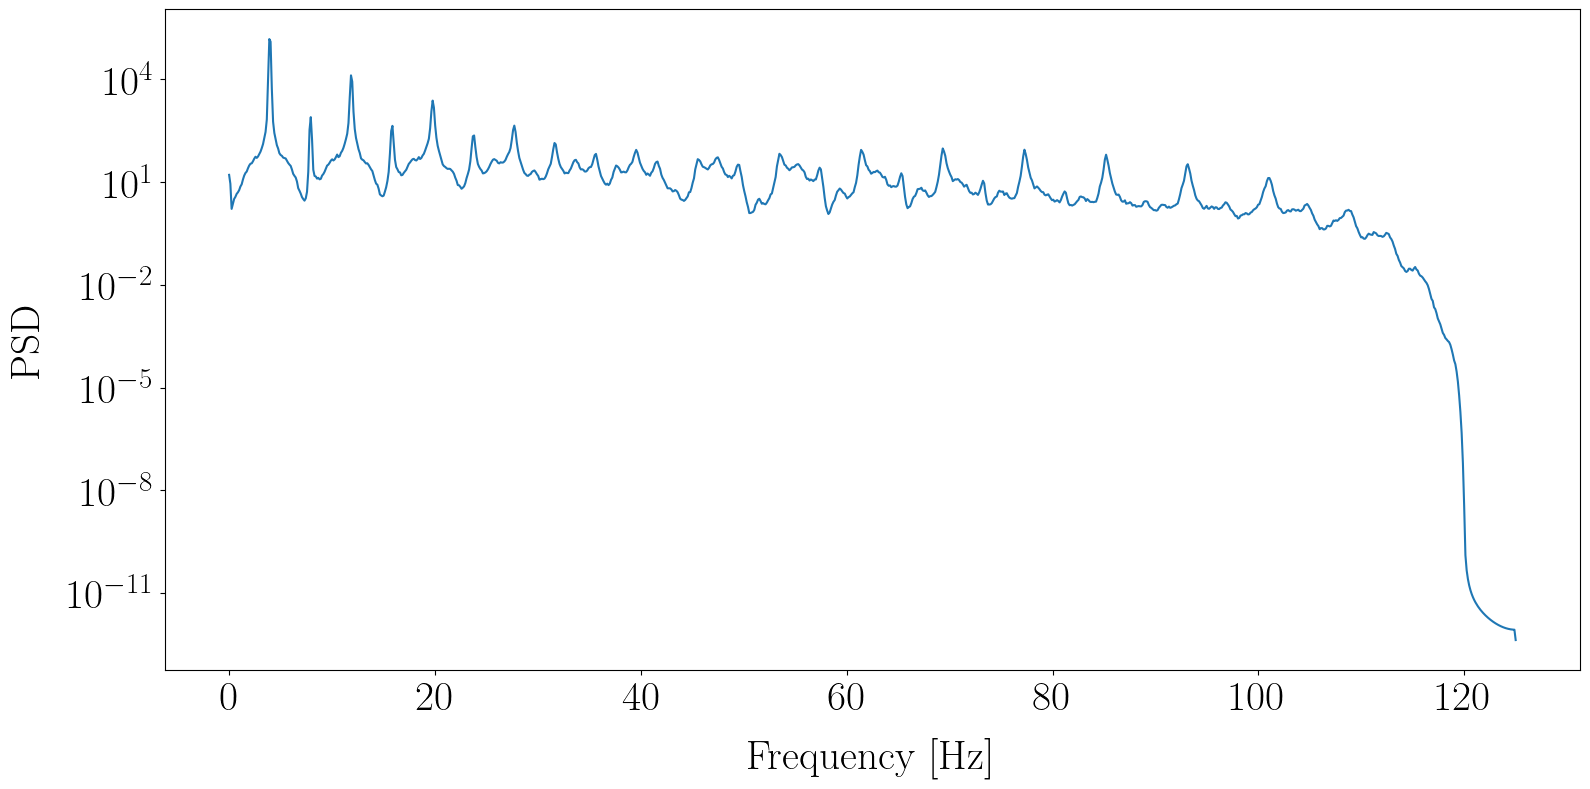

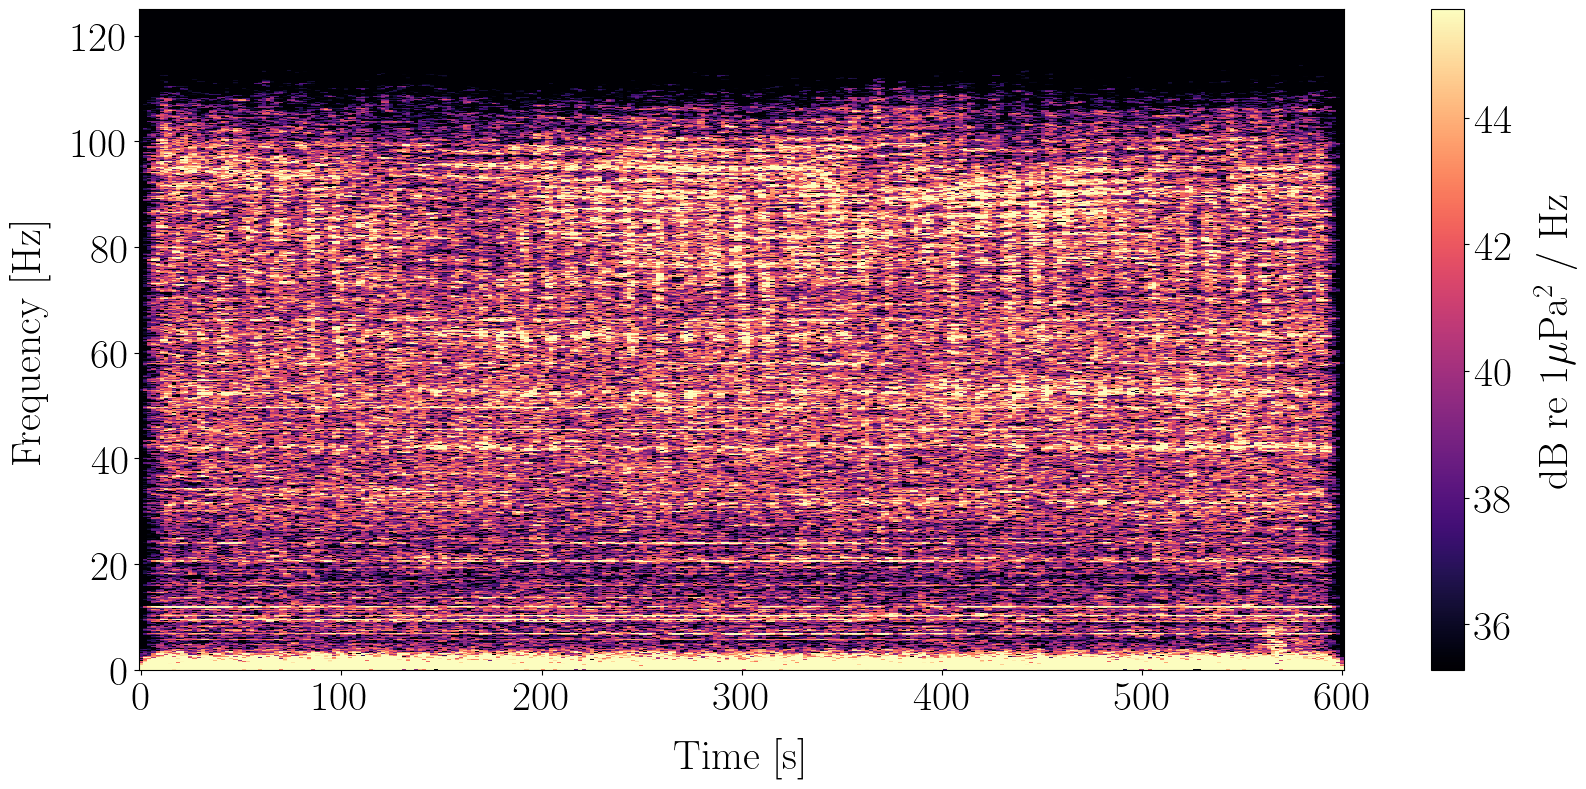

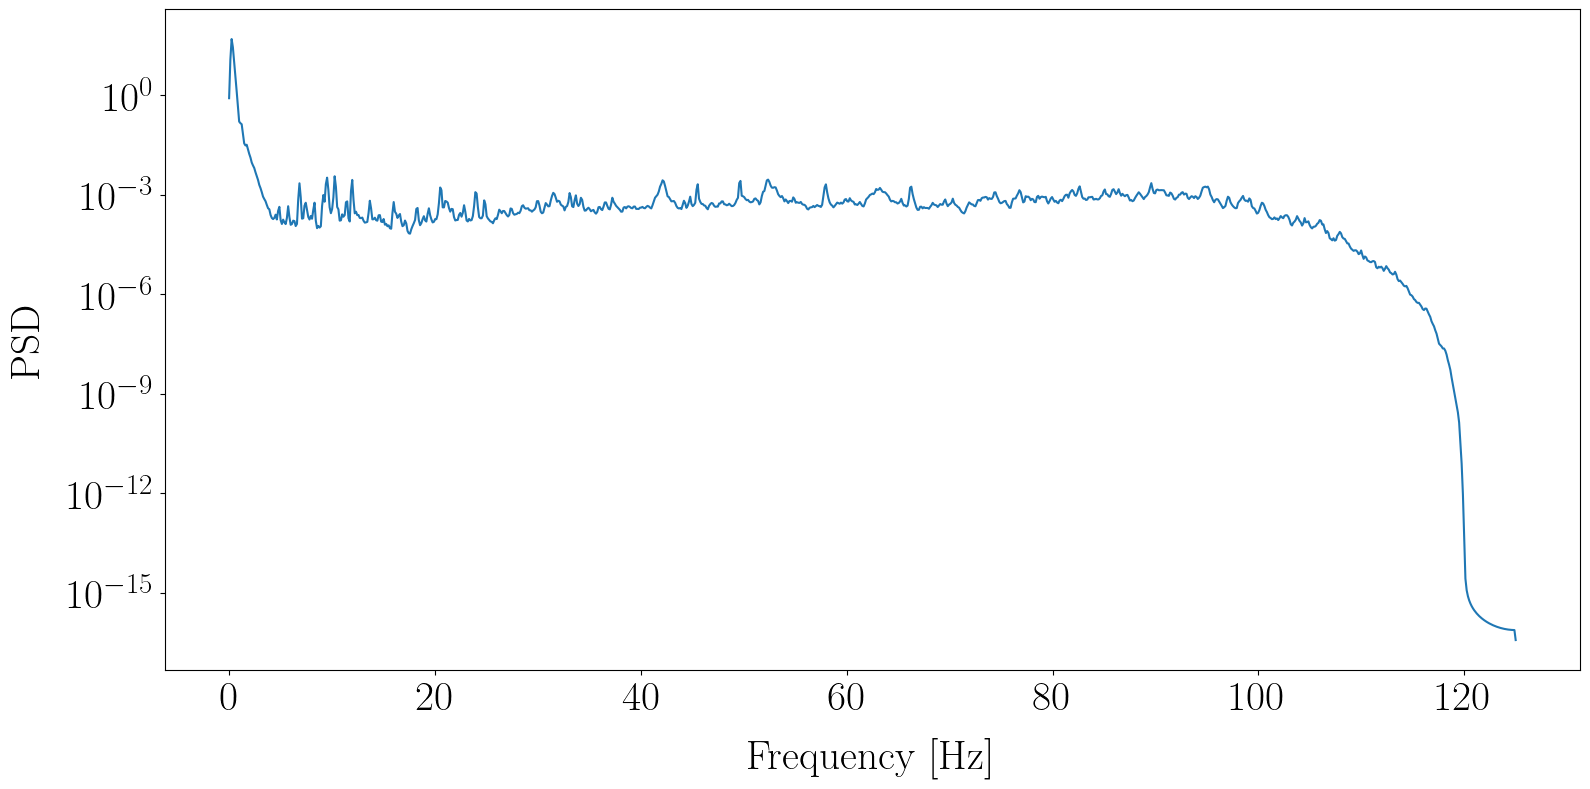

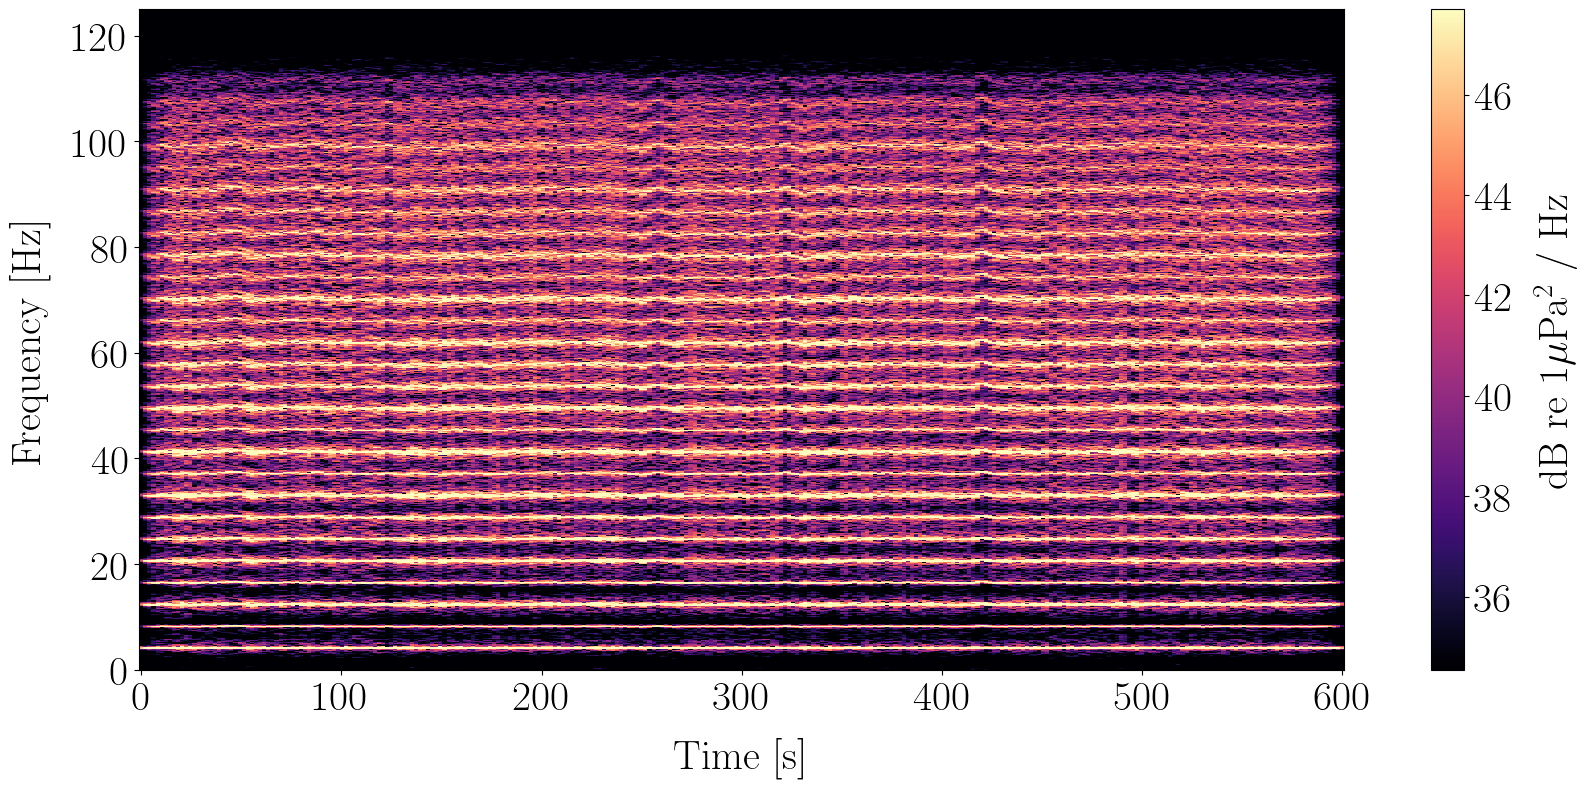

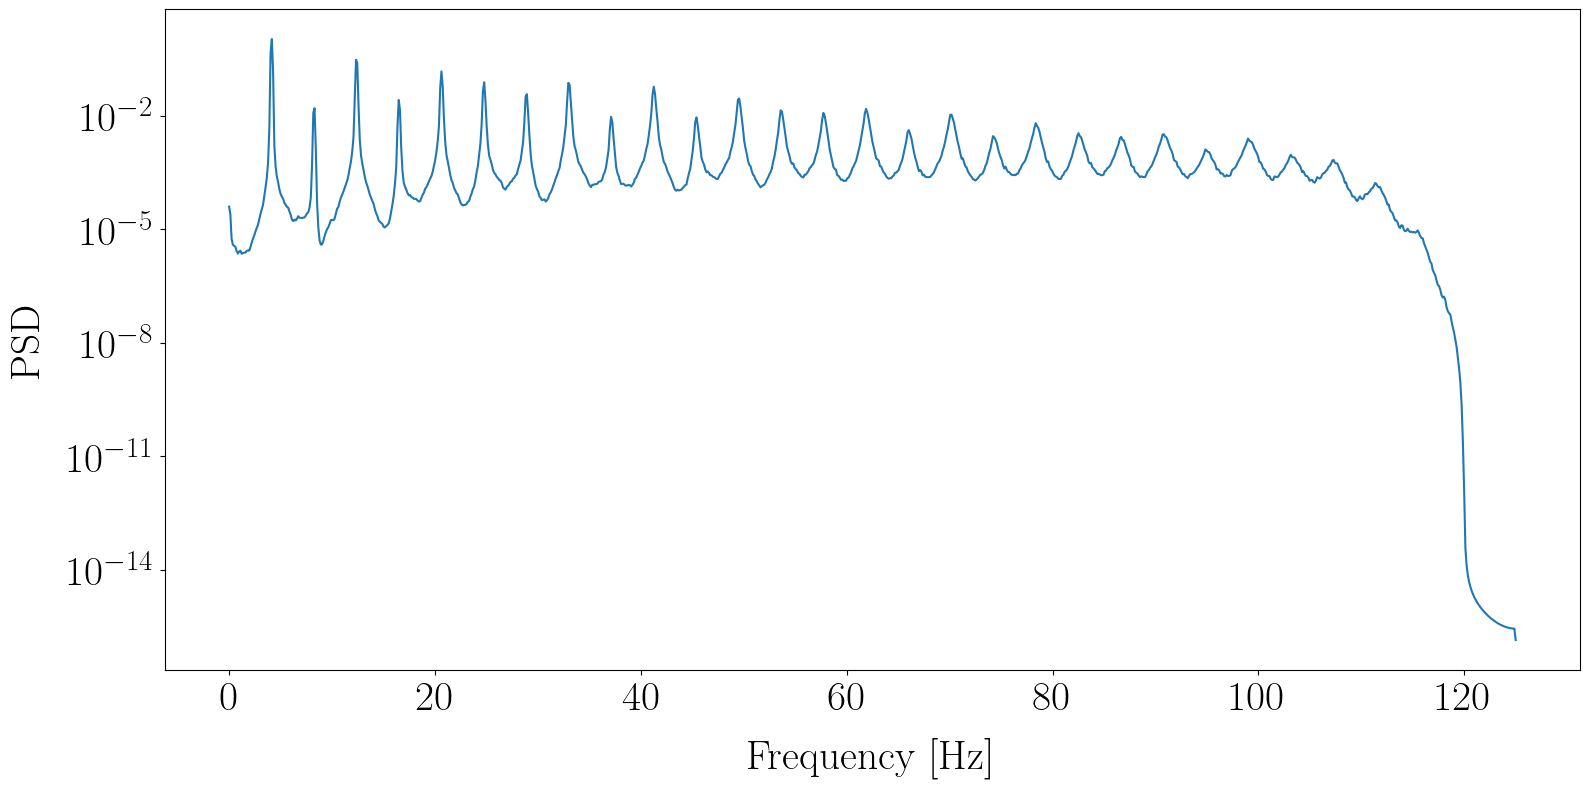

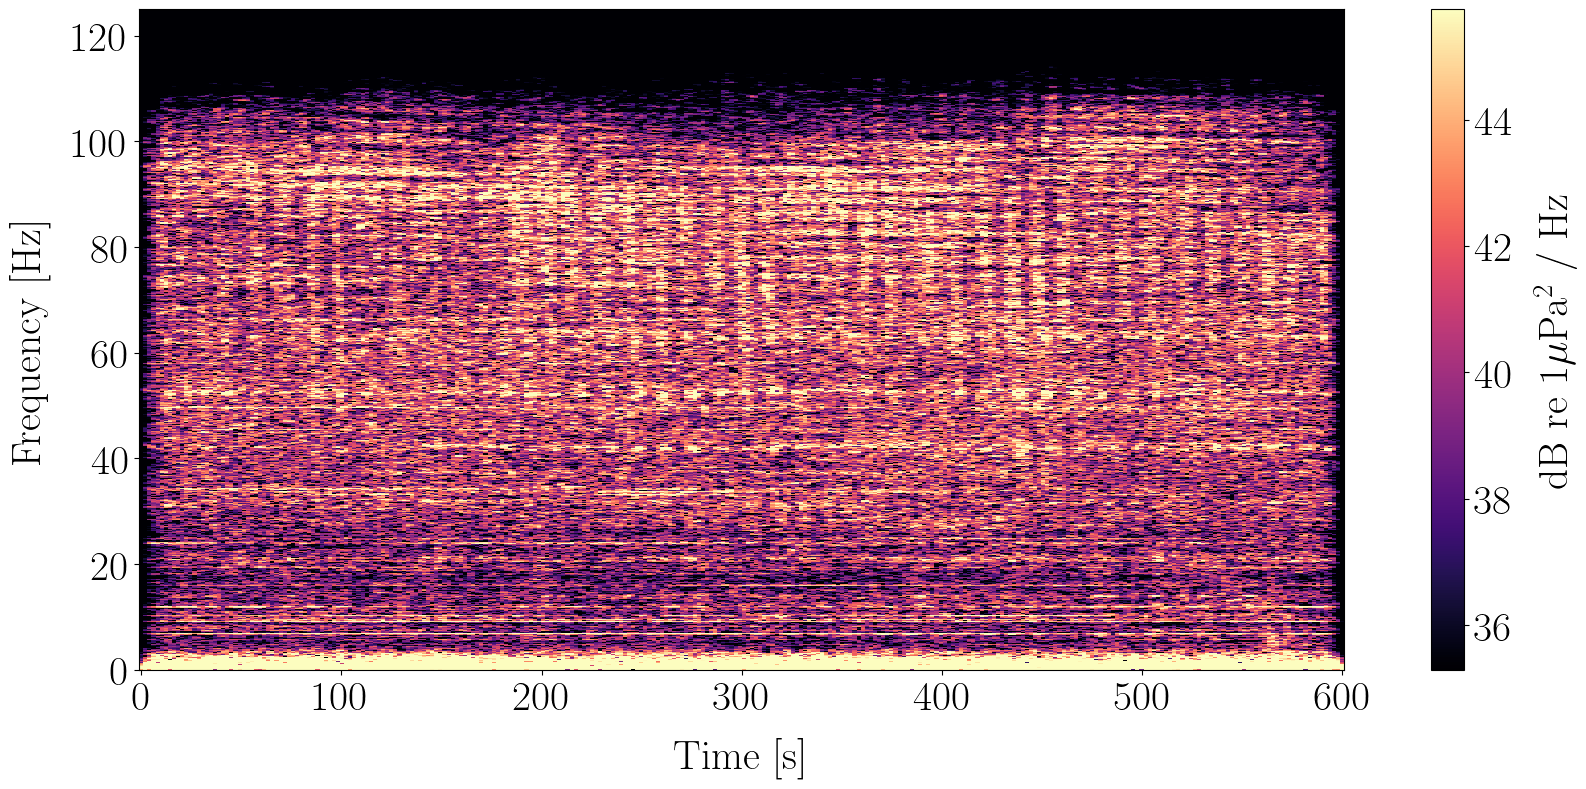

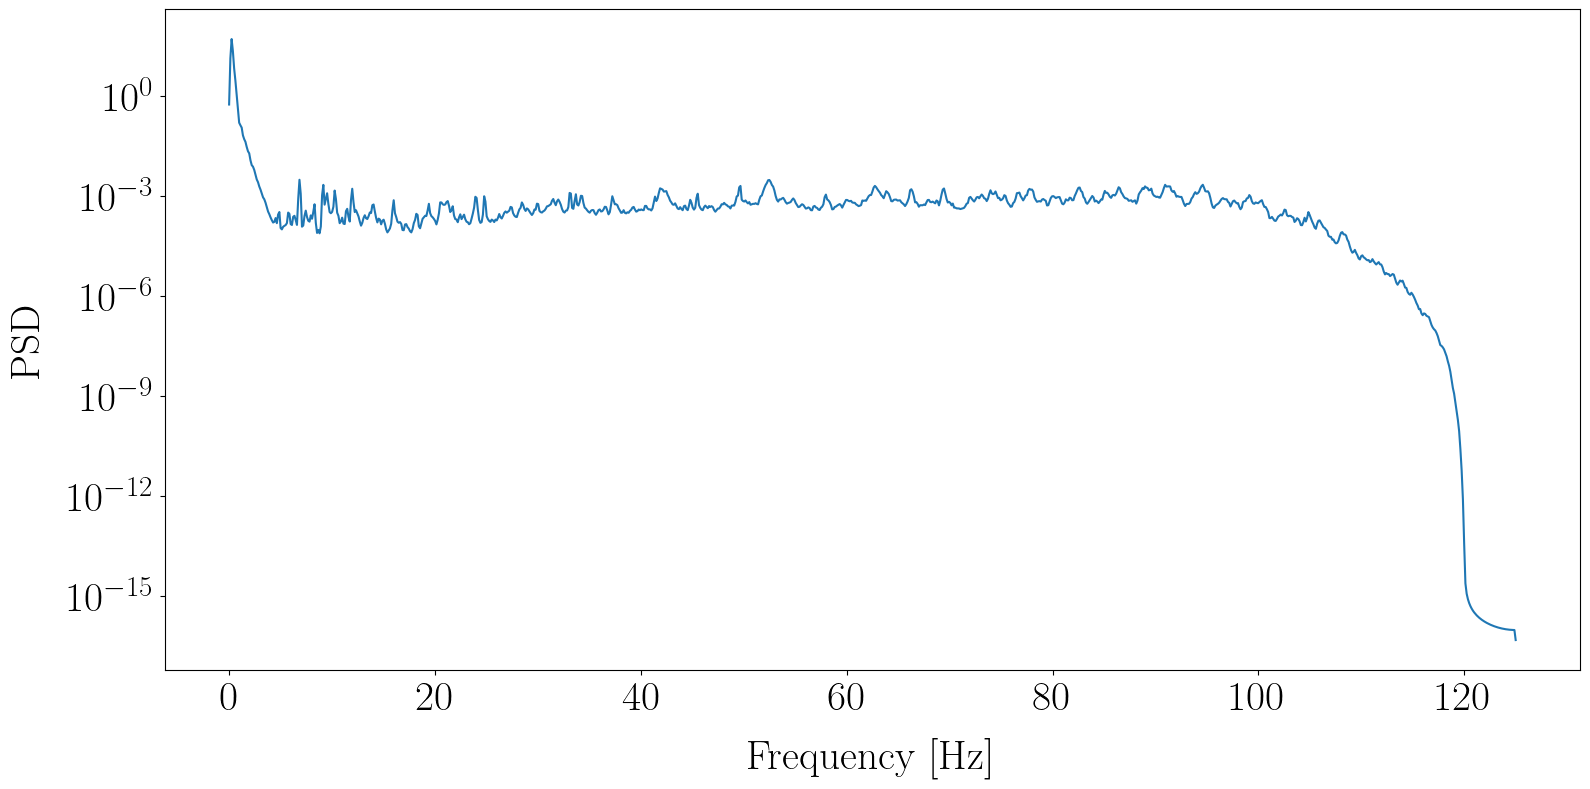

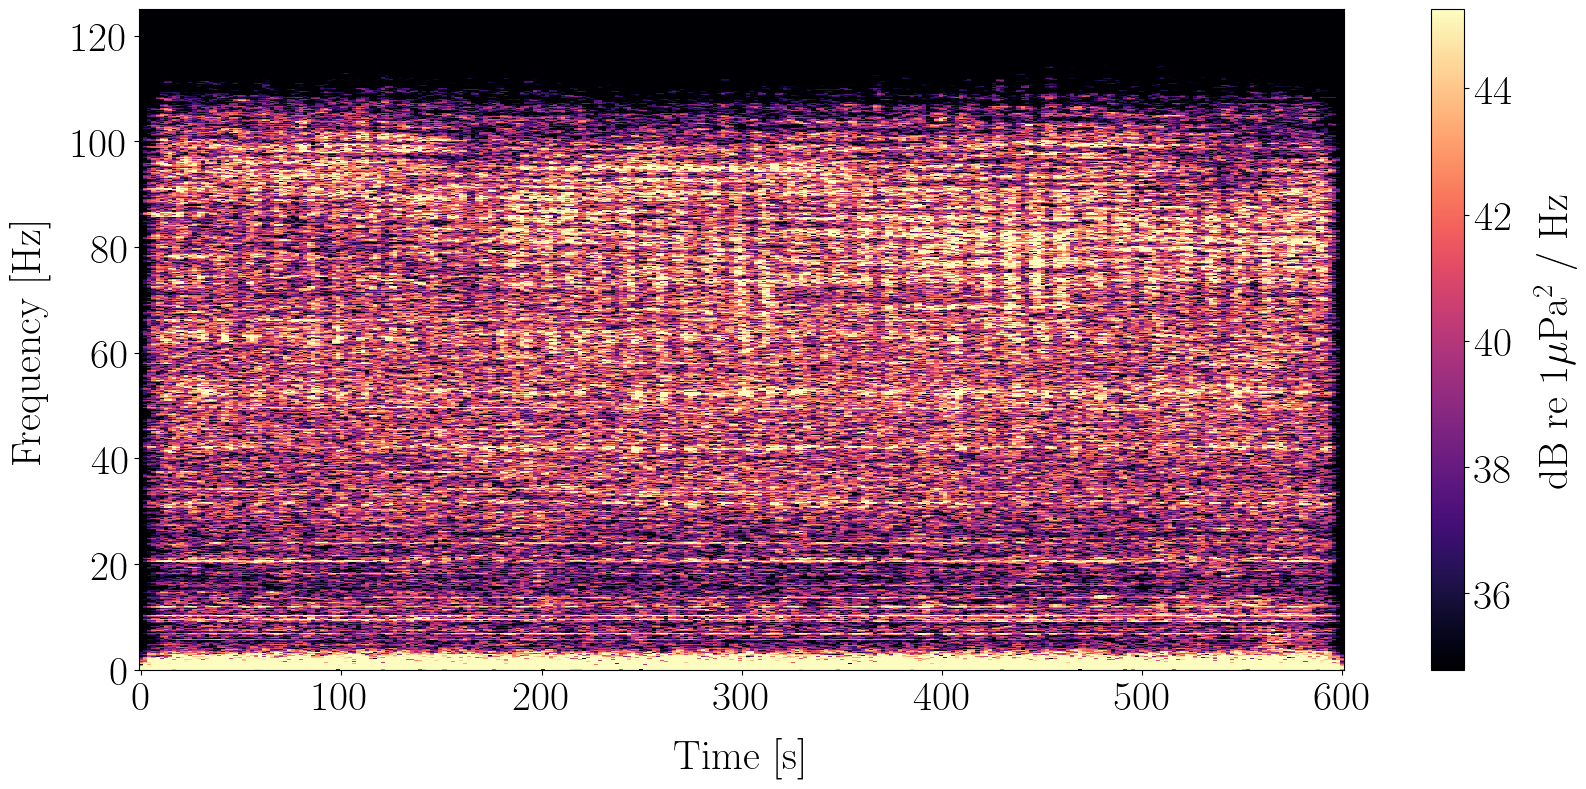

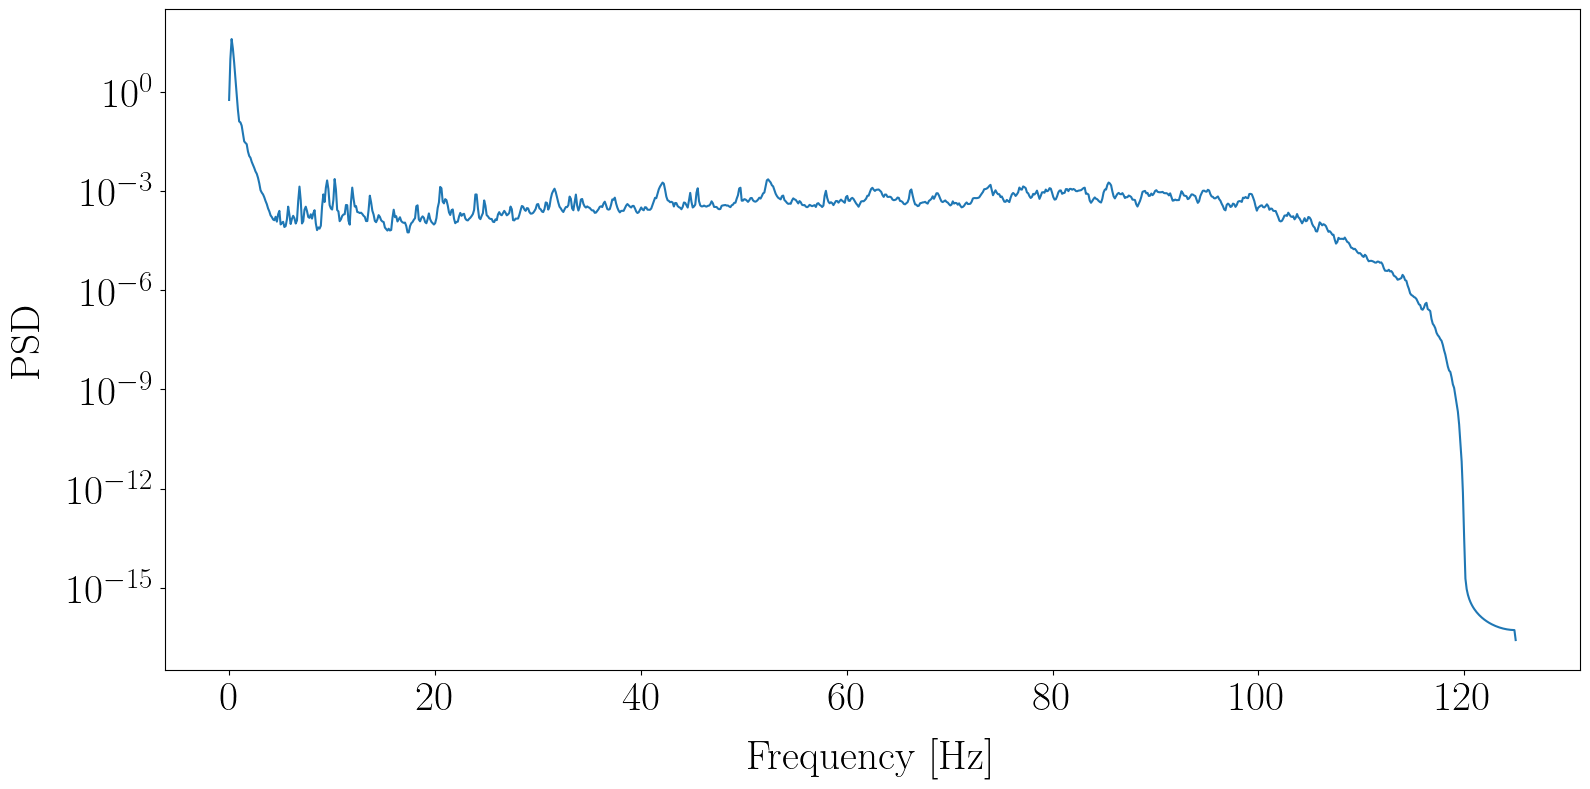

In [6]:
import pandas as pd
from stage_Ruth.utils import process_and_plot

# ============================================================
# ⚙️ CONFIG
# ============================================================

data_info = {
    "client": "IRIS",
    "network": "IM",
    "stations": ["CY301", "CY302", "CY303", "CY305", "CY306"],
    "channel": "EDH",
    "start_time": pd.to_datetime("2024-12-25"),
    "end_time": pd.to_datetime("2024-12-25") + pd.Timedelta(minutes=10),
}

# ============================================================
# 🚀 RUN PIPELINE
# ============================================================
root_selection_img = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\stage_Ruth\img"

st, inv = process_and_plot(
    data_info,
    pre_filt=(0.05, 0.1, 100, 120),
    save_figures=True,
    save_path=root_selection_img,
    plot_map=True,
)

In [8]:
# Get data
cli = filtered_stations.iloc[0]["client"]
client = Client(cli)

# We need to set manually some informations because the metadata scrapped with the Obspy API does not always match reality.
network = filtered_stations.iloc[0]["network"]
stations = [f"CY30{i}" for i in [1, 2, 3, 5, 6]]
# stations = ["CY306"]
ch = "EDH"
duration =  6 * 60 * 10  # 10 minutes
start_time = pd.to_datetime("2024-12-25")
# start_time = pd.to_datetime(
# "2017-07-15"
# )  # According to https://ds.iris.edu/mda/IM/CY306/?starttime=2017-07-11T00:00:00&endtime=2599-12-31T23:59:59 the available data period start on Earliest: 2024-12-19T17:31:09.644000Z
end_time = start_time + pd.Timedelta(seconds=duration)

data_info = {
    "client": cli,
    "network": network,
    "stations": stations,
    "channel": ch,
    "start_time": start_time,
    "end_time": end_time,
}
get_data(data_info)

c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\obspy\clients\fdsn\client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)


**Structure de Inventory dans ObsPy**
L’objet Inventory est hiérarchique

Inventory

    └── Network (IM)
        
        └── Station (CY301, CY302, ...)
            
            └── Channel (EDH, ...)
                
                └── Response

# 📡 Structure de l’objet `Trace` dans ObsPy

Un objet `Trace` représente **une seule série temporelle** (un signal) provenant d’un capteur donné.

Ici :
IM.CY301..EDH | 2024-12-25T00:00:00 - 2024-12-25T06:00:00 | 250.0 Hz

Un 'Trace' est composé de deux parties principales :

```python
trace.data   # les données (numpy array)
trace.stats  # les métadonnées (header)

Un Trace ne contient pas directement la réponse instrumentale, pour corriger la réponse du capteur il faut utiliser les métadonnées de l objet Inventory:

tr.remove_response(inventory=inv)

In [9]:
# Load data
root_folder = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\data\wav\bruit_fm\data_selection"
station_id_root = stations[0][0:3]
fname = f"{network}_{station_id_root}_{start_time.strftime('%Y%m%d_%H%M')}_{end_time.strftime('%Y%m%d_%H%M')}"
fpath = os.path.join(root_folder, fname)
st = obspy_read(fpath + ".mseed", format="MSEED")
inv = obspy_read_inventory(fpath + ".xml", format="STATIONXML")

In [10]:
print(inv)
print(st)

Inventory created at 2026-04-07T13:40:56.954956Z
	Created by: ObsPy 1.5.0
		    https://www.obspy.org
	Sending institution: IRIS-DMC,ObsPy 1.5.0 (IRIS-DMC)
	Contains:
		Networks (5):
			IM (5x)
		Stations (5):
			IM.CY301 (RAF Akrotiri, Cyprus, Site CY301)
			IM.CY302 (RAF Akrotiri, Cyprus, Site CY302)
			IM.CY303 (RAF Akrotiri, Cyprus, Site CY303)
			IM.CY305 (RAF Akrotiri, Cyprus, Site CY305)
			IM.CY306 (RAF Akrotiri, Cyprus, Site CY306)
		Channels (5):
			IM.CY301..EDH, IM.CY302..EDH, IM.CY303..EDH, IM.CY305..EDH, 
			IM.CY306..EDH
5 Trace(s) in Stream:
IM.CY301..EDH | 2024-12-25T00:00:00.000000Z - 2024-12-25T01:00:00.000000Z | 250.0 Hz, 900001 samples
IM.CY302..EDH | 2024-12-25T00:00:00.000000Z - 2024-12-25T01:00:00.000000Z | 250.0 Hz, 900001 samples
IM.CY303..EDH | 2024-12-25T00:00:00.000000Z - 2024-12-25T01:00:00.000000Z | 250.0 Hz, 900001 samples
IM.CY305..EDH | 2024-12-25T00:00:00.000000Z - 2024-12-25T01:00:00.000000Z | 250.0 Hz, 900001 samples
IM.CY306..EDH | 2024-12-25T00:00

In [11]:
for net in inv:
    for sta in net:
        print(f"Station {sta.code}")
        print("  Latitude:", sta.latitude)
        print("  Longitude:", sta.longitude)
        print("  Elevation:", sta.elevation)
        print("  Start:", sta.start_date)
        print("  End:", sta.end_date)

Station CY301
  Latitude: 33.30031
  Longitude: 33.05407
  Elevation: -1690.0
  Start: 2023-12-23T00:00:00.000000Z
  End: None
Station CY302
  Latitude: 33.29619
  Longitude: 33.04393
  Elevation: -1691.0
  Start: 2017-07-11T00:00:00.000000Z
  End: None
Station CY303
  Latitude: 33.31014
  Longitude: 33.05351
  Elevation: 1719.0
  Start: 2017-07-11T00:00:00.000000Z
  End: None
Station CY305
  Latitude: 33.31119
  Longitude: 33.0425
  Elevation: -1696.0
  Start: 2024-09-10T00:00:00.000000Z
  End: None
Station CY306
  Latitude: 33.30332
  Longitude: 33.03706
  Elevation: -1699.0
  Start: 2017-07-11T00:00:00.000000Z
  End: None


In [12]:
# <!-- La note ci-dessous correspond au cas où l'on ne précise pas l'intervalle de temps visé dans l'appel à client.get_stations (dans le fonction get_data). Ce problème a depuis été modifié.  

# Les notations (x2) à coter des stations désignent les stations pour lesquelles il y a plusieurs définitions valides de la même station dans l'intervalle de temps de la requête. Une station égale une section du fichier XML correspondant. Néanmoins, les données ne sont accessibles qu'à partir de 2024-12-24 et donc une seule de ces stations est utilisable. Ainsi, il n'y a que 5 trace dans l'objet Stream. 


# Le serveur renvoie toutes les versions temporelles de la station, pas seulement celle utile pour l'intervalle de la requête.

# Par exemple pour CY301 : 

# | Version | Période            |
# | ------- | ------------------ |
# | v1      | 2017 → 2019        |
# | v2      | 2023 → aujourd’hui | -->


In [13]:
# st.filter(
#     "bandpass",
#     freqmin=2,
#     freqmax=100,
#     corners=4,
#     zerophase=True,
# )

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


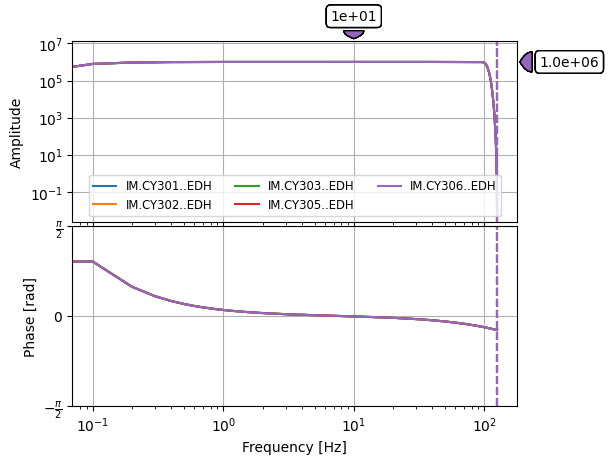

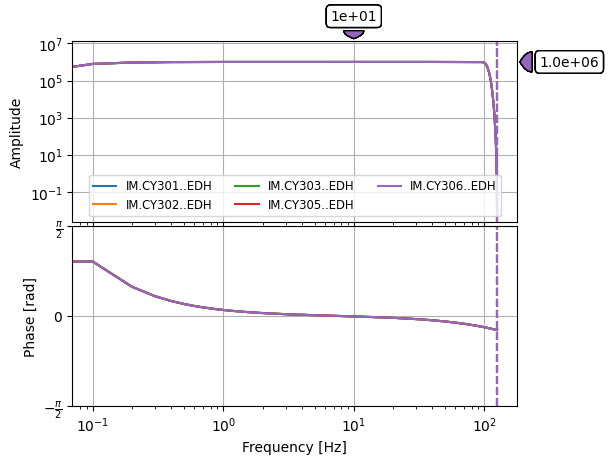

In [15]:
# Plot response 
inv.plot_response(min_freq=0.1)

**A propos de la méthode st.remove_response()**

Cette fonction permet de déconvoluer la réponse du capteur afin de remonter au signal physique. 

remove_response(
    inventory,
    output="VEL",
    water_level=60,
    pre_filt=None,
    zero_mean=True,
    taper=True,
    taper_fraction=0.05,
    plot=False
)

inventory=inv

👉 Objet Inventory contenant :

stations
canaux
réponse instrumentale

⚠️ Doit correspondre au Trace (même station, même période)

output="DEF"

Définit l’unité du signal en sortie :

| Valeur   | Signification                                          |
| -------- | ------------------------------------------------------ |
| `"DISP"` | déplacement (m)                                        |
| `"VEL"`  | vitesse (m/s)                                          |
| `"ACC"`  | accélération (m/s²)                                    |
| `"DEF"`  | unité native du capteur (ex: pression pour hydrophone) |

Pour un hydrophone (EDH) :
➡️ généralement "DEF" (pression)

pre_filt=(f1, f2, f3, f4)

Filtre passe-bande appliqué avant la déconvolution

évite les instabilités numériques
limite la correction aux fréquences fiables

| Fréquence | Effet                |
| --------- | -------------------- |
| < f1      | supprimé             |
| f1 → f2   | montée progressive   |
| f2 → f3   | bande utile          |
| f3 → f4   | descente progressive |
| > f4      | supprimé             |

water_level=60

👉 Stabilisation de la déconvolution

empêche la division par des valeurs trop faibles
agit comme un seuil minimal

👉 Valeurs typiques :

10 → peu de stabilisation
60 → standard
100 → très stable mais moins précis

zero_mean=True

👉 Supprime la moyenne du signal avant traitement

évite les biais DC
améliore la stabilité de la FFT

plot=True

👉 Affiche un diagnostic :

réponse instrumentale
effet du filtre
spectres

5 Trace(s) in Stream:
IM.CY301..EDH | 2024-12-25T00:00:00.000000Z - 2024-12-25T01:00:00.000000Z | 250.0 Hz, 900001 samples
IM.CY302..EDH | 2024-12-25T00:00:00.000000Z - 2024-12-25T01:00:00.000000Z | 250.0 Hz, 900001 samples
IM.CY303..EDH | 2024-12-25T00:00:00.000000Z - 2024-12-25T01:00:00.000000Z | 250.0 Hz, 900001 samples
IM.CY305..EDH | 2024-12-25T00:00:00.000000Z - 2024-12-25T01:00:00.000000Z | 250.0 Hz, 900001 samples
IM.CY306..EDH | 2024-12-25T00:00:00.000000Z - 2024-12-25T01:00:00.000000Z | 250.0 Hz, 900001 samples

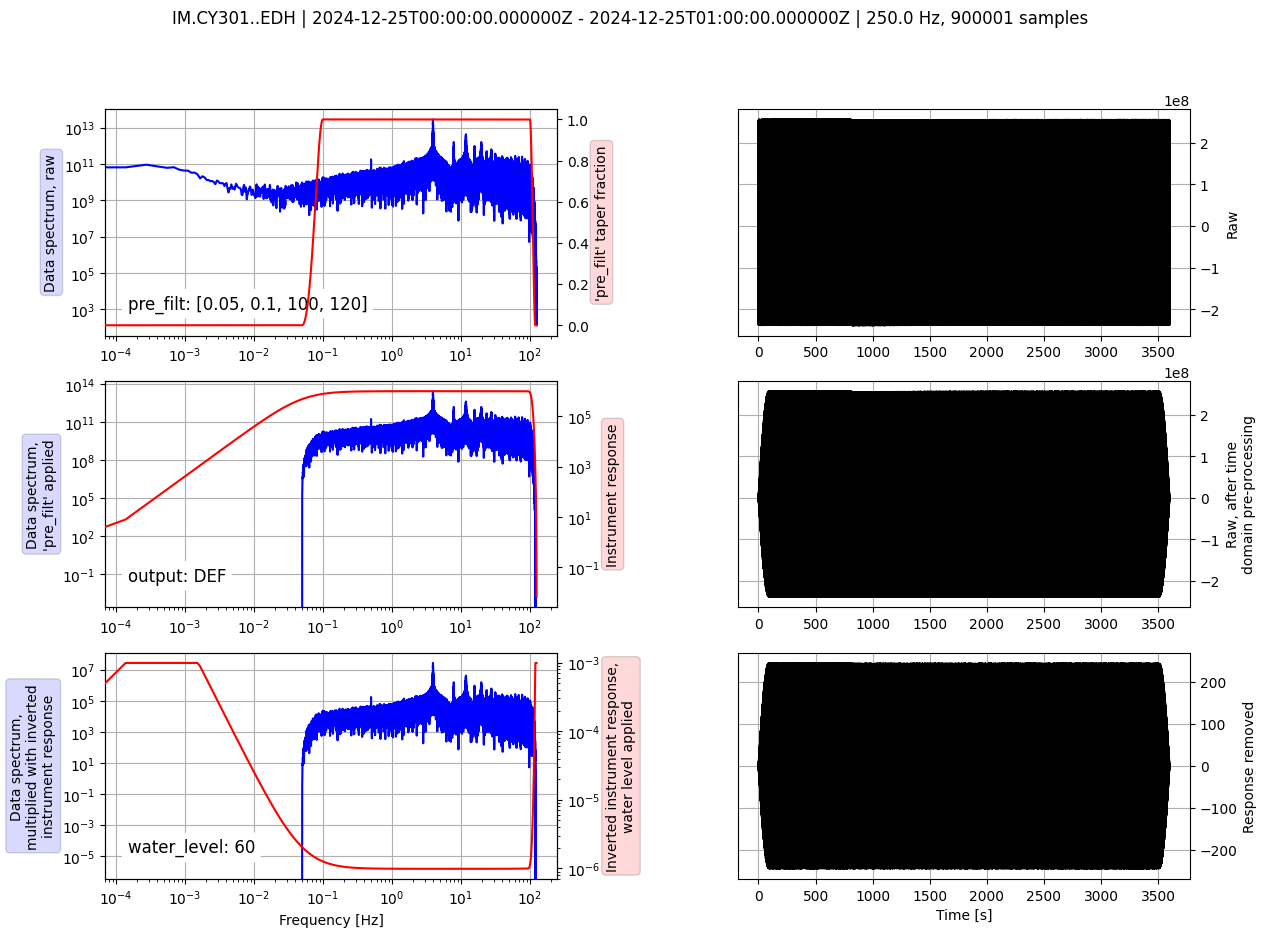

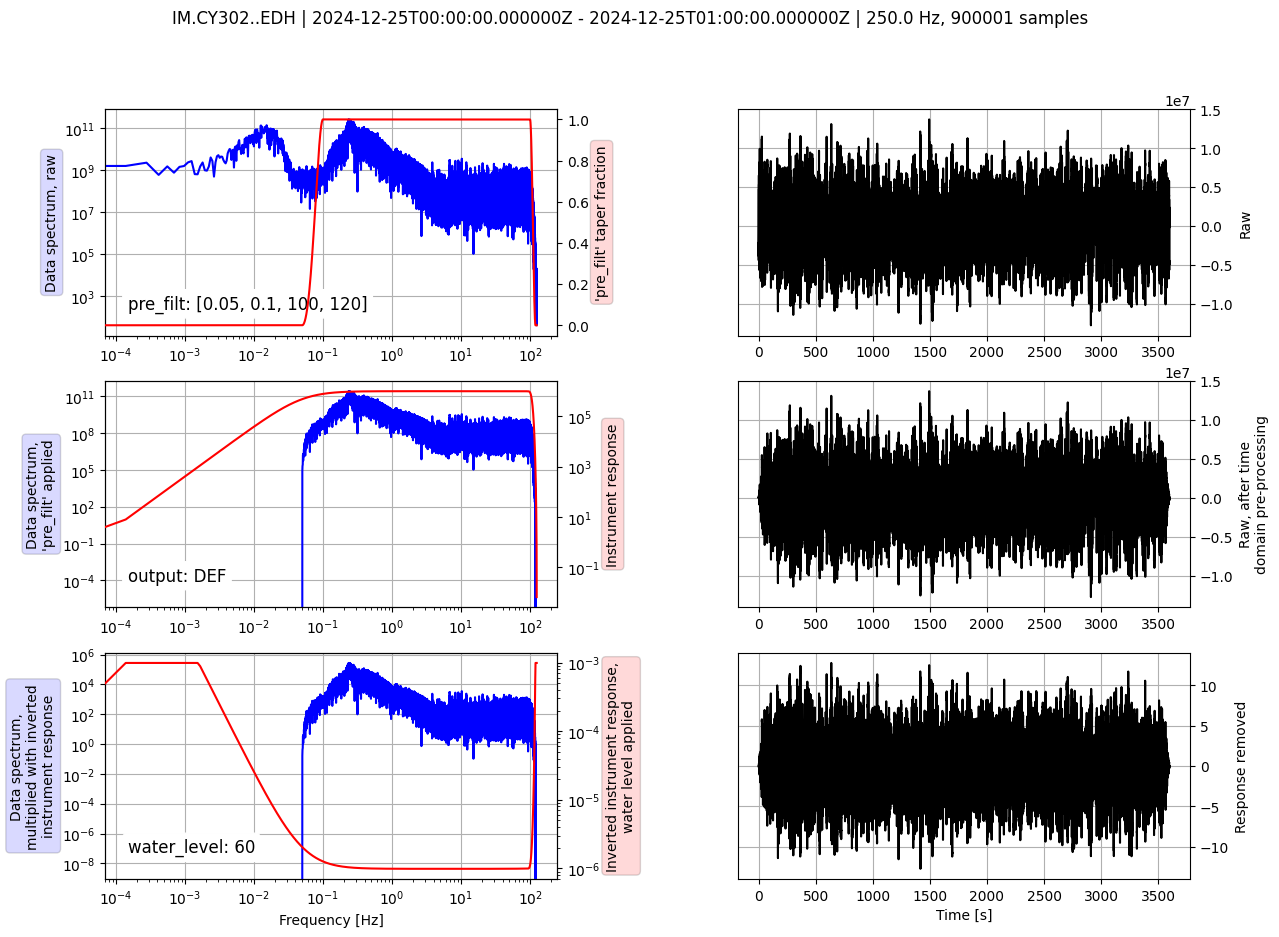

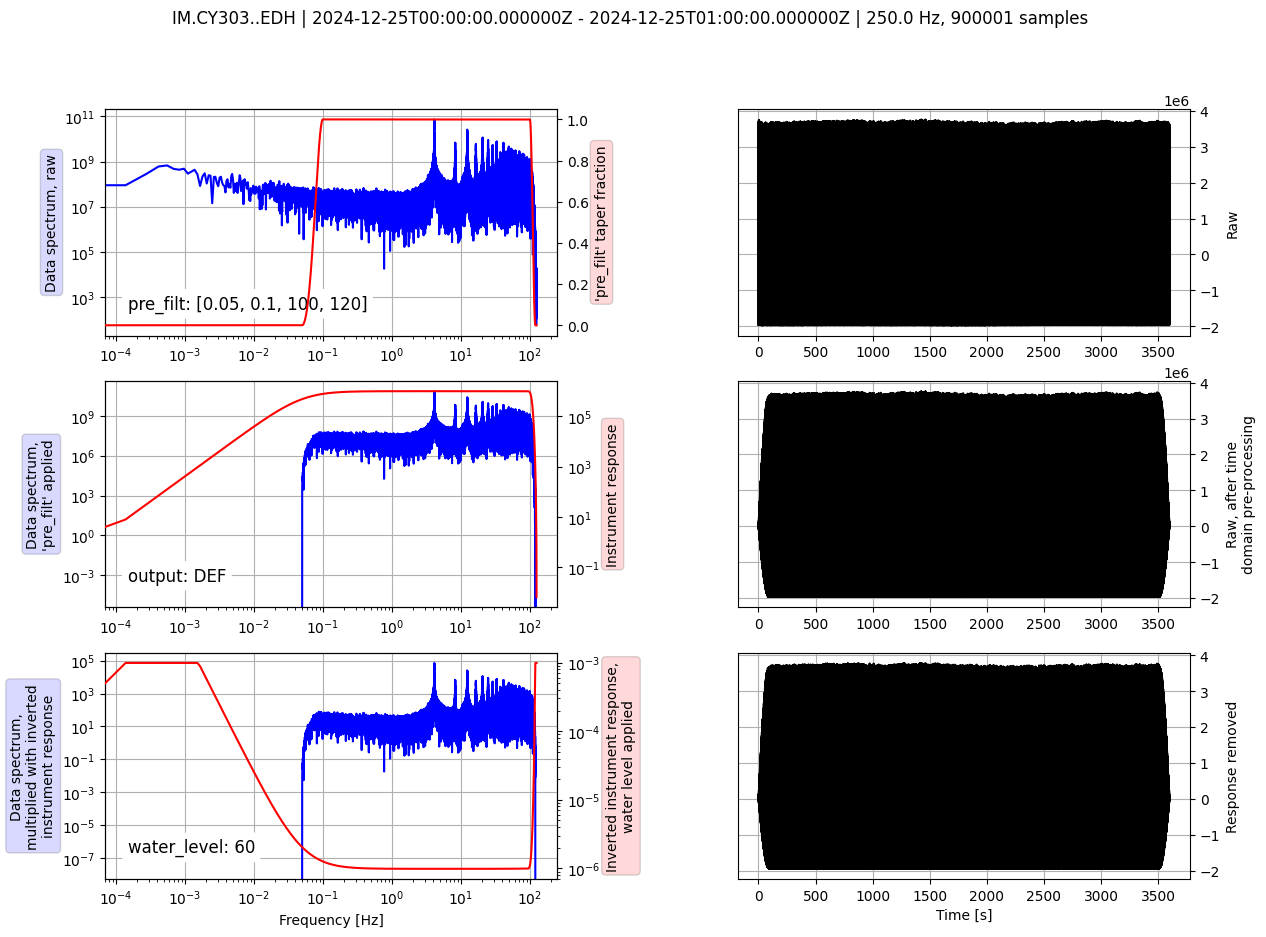

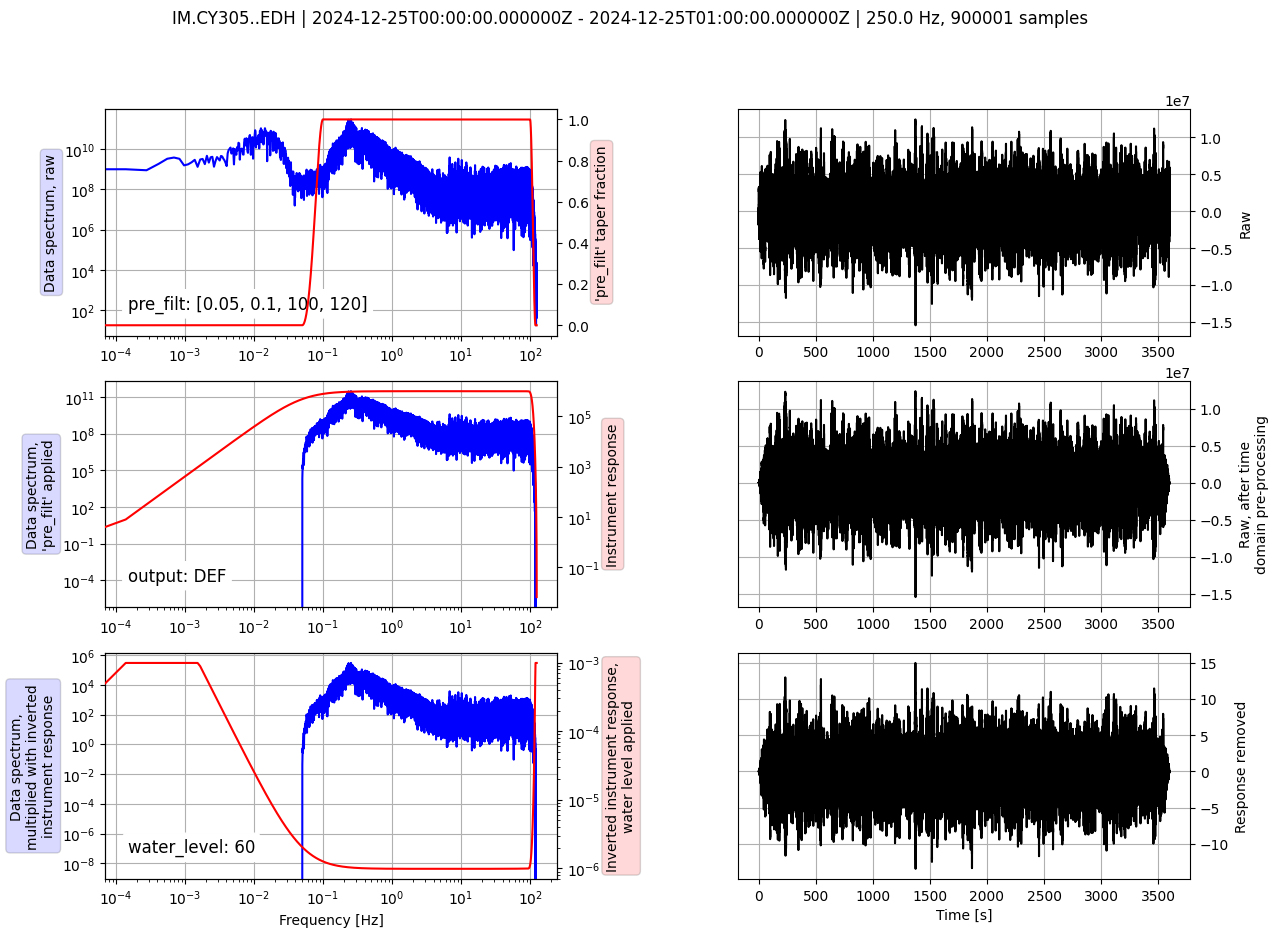

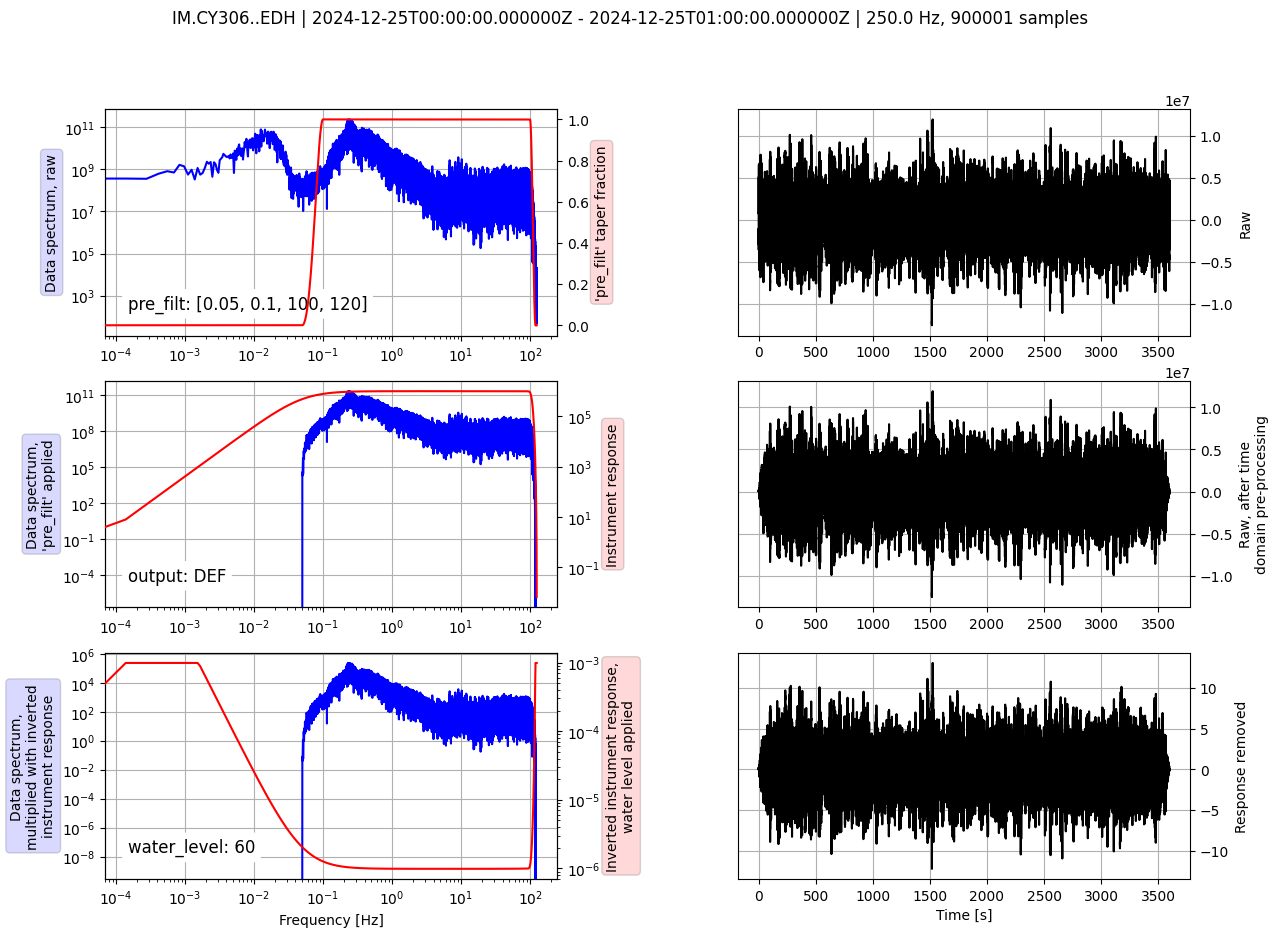

In [17]:
# st.remove_response(inventory=inv)
st.remove_response(
    inventory=inv,
    output="DEF",
    pre_filt=(0.05, 0.1, 100, 120),
    water_level=60,
    plot=True,
)

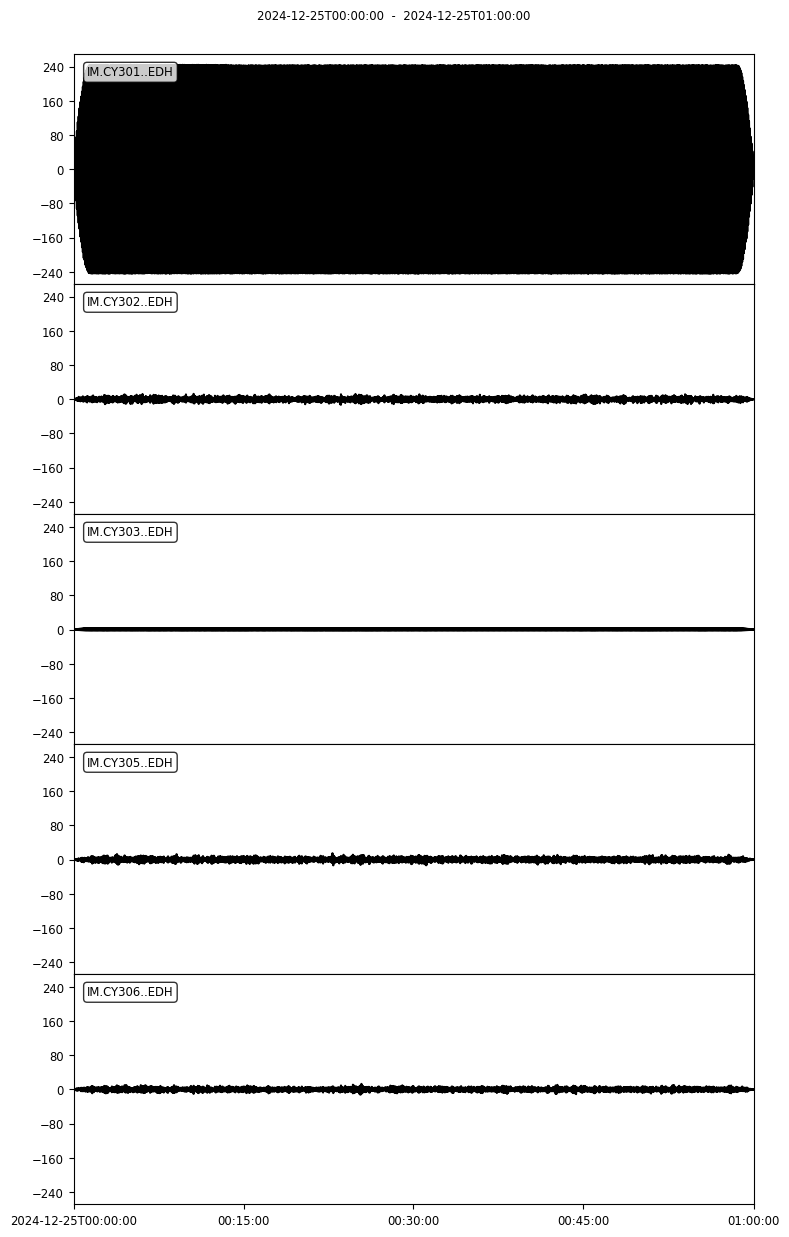

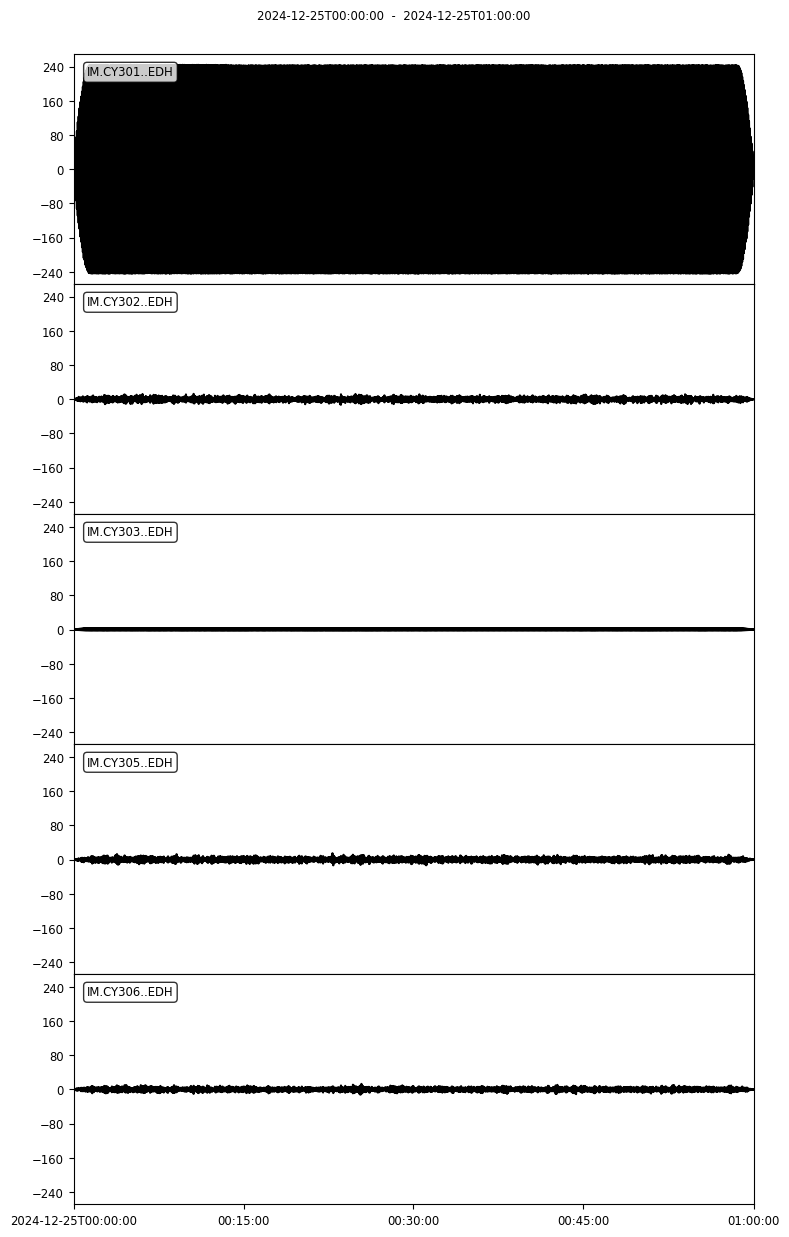

In [18]:
st.plot()

In [19]:
# st.remove_sensitivity(inventory=inv)

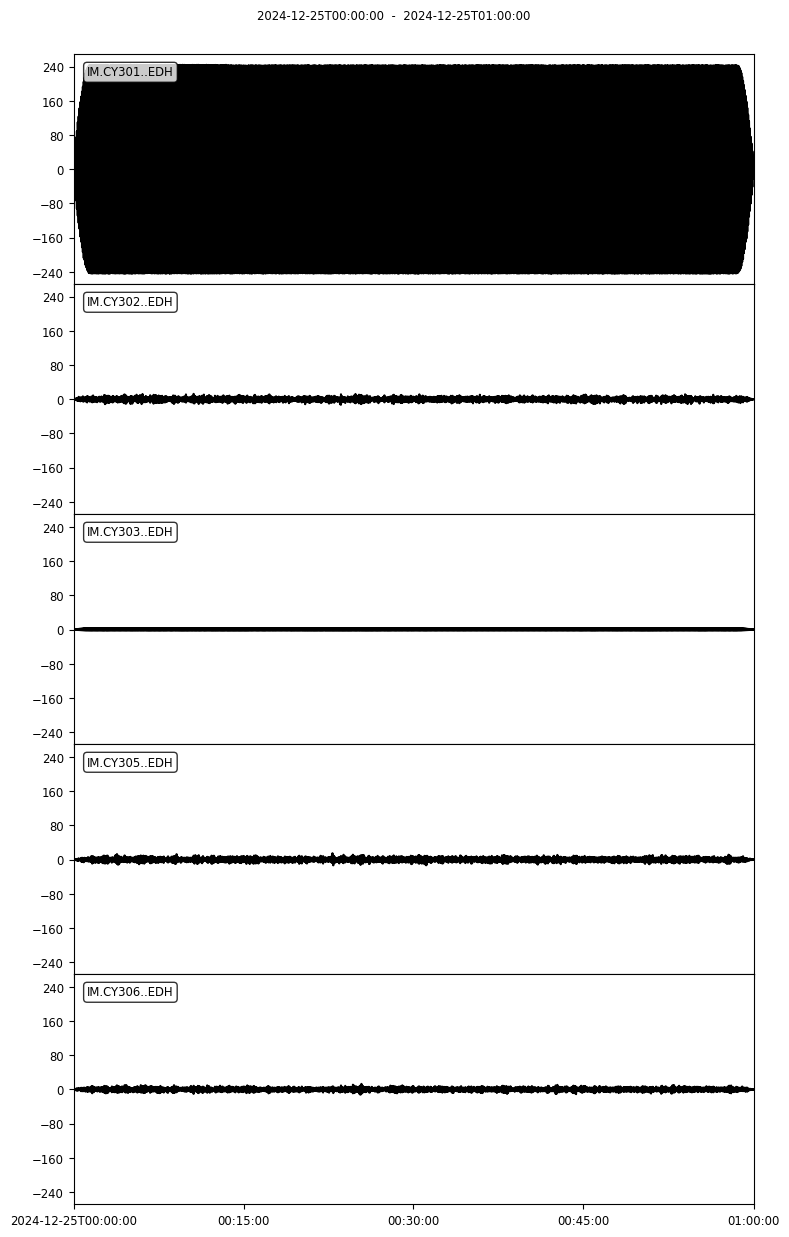

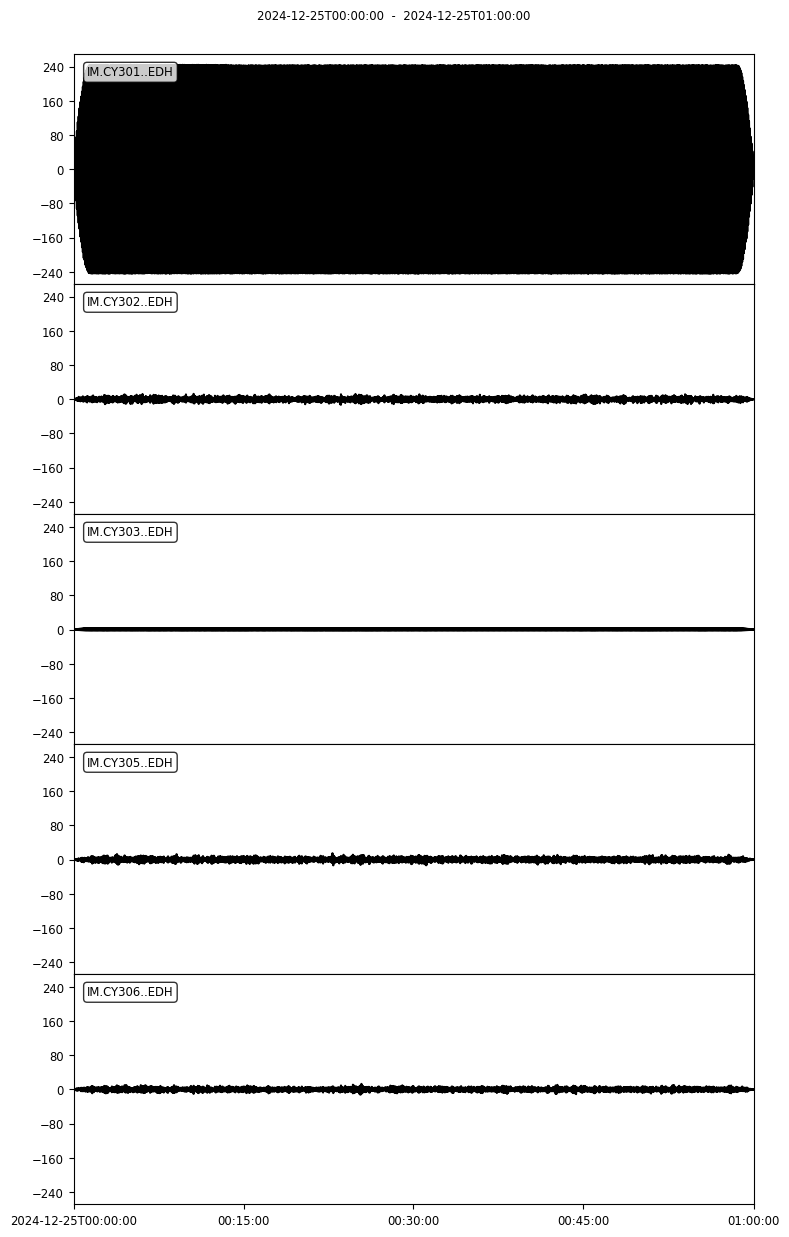

In [20]:
st.plot()

In [21]:
# st.spectrogram()


In [22]:
p0 = 1e-6
for tr in st:
    t = tr.data.copy()
    p_rms = np.sqrt(np.mean(t**2))

    spl = 20 * np.log10(p_rms / p0)
    print(f"SPL for {tr.id}: {spl:.1f} dB re 1uPa")


SPL for IM.CY301..EDH: 166.2 dB re 1uPa
SPL for IM.CY302..EDH: 130.6 dB re 1uPa
SPL for IM.CY303..EDH: 117.0 dB re 1uPa
SPL for IM.CY305..EDH: 130.6 dB re 1uPa
SPL for IM.CY306..EDH: 129.4 dB re 1uPa


c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\obspy\imaging\waveform.py:419: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(xmin, xmax)


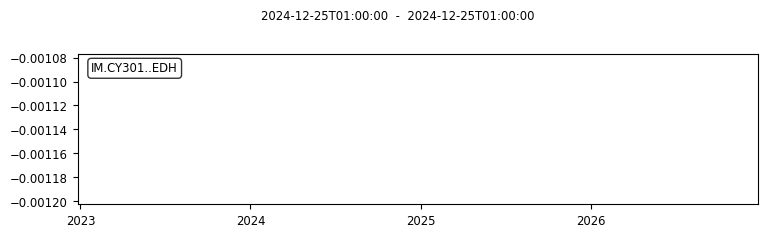

c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\scipy\signal\_spectral_py.py:1613: UserWarning: nperseg = 2048 is greater than input length  = 1, using nperseg = 1
  freqs, time, Zxx = _spectral_helper(x, x, fs, window, nperseg, noverlap,


ValueError: noverlap must be less than nperseg.

In [23]:
# Derive and plot spectrogram
nperseg = 2**11
noverlap = int(nperseg * 0.75)
tr = st[0].copy()
data_sample = tr.trim(
    starttime=tr.stats.starttime + 60 * 60,
    endtime=tr.stats.starttime + 60 * 60 +   5*60*60,
)
data_sample.plot()
ff, tt, Sxx = sp.stft(
    data_sample,
    fs=tr.stats.sampling_rate,
    nperseg=nperseg,
    noverlap=noverlap,
    scaling="psd",
)

In [ ]:
LargeFigure()
plt.figure()
sxx_log = 10 * np.log10(np.abs(Sxx))
plt.pcolormesh(
    tt,
    ff,
    sxx_log,
    # shading="gouraud",
    cmap="magma",
    vmin=np.percentile(sxx_log, 20),
    vmax=np.percentile(sxx_log, 95),
)
plt.colorbar(label=r"Pa$^2$ / Hz in dB")
plt.ylabel("Frequency [Hz]")
plt.xlabel("Time [sec]")

In [ ]:
# Derive and plot PSD

f, Pxx = signal.welch(
    tr.data,
    fs=tr.stats.sampling_rate,
    nperseg=nperseg,
    noverlap=noverlap,
    scaling="density",
)

LargeFigure()
plt.figure()
plt.semilogy(f, Pxx)
plt.xlabel("Frequency [Hz]")
plt.ylabel(r"Pa$^2$ / Hz")

plt.xlim(1, 100)

In [ ]:
img_root = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\data\wav\bruit_fm\data_selection\img\demo_6h"

In [ ]:
# Intercorrélation deux stations

tr1 = st[-2].copy()
tr2 = st[-1].copy()

delay_start = 0 * 60 * 60
sig_duration = 6 * 60 * 60
sig_1 = tr1.trim(
    starttime=tr1.stats.starttime + delay_start,
    endtime=tr1.stats.starttime + delay_start + sig_duration,
)

sig_2 = tr2.trim(
    starttime=tr2.stats.starttime + delay_start,
    endtime=tr2.stats.starttime + delay_start + sig_duration,
)

# plt.figure()
sig_1.plot()
fig = plt.gcf()
fpath = os.path.join(img_root, f"sig_{sig_1.stats.station}.png")
fig.savefig(fpath)

plt.figure()
sig_2.plot()
fpath = os.path.join(img_root, f"sig_{sig_2.stats.station}.png")
plt.savefig(fpath)


In [ ]:
fs = sig_1.stats.sampling_rate
nperseg = 2**10
noverlap = int(nperseg * 0.75)
ff, tt, stft_1 = sp.stft(sig_1, fs=fs, nperseg=nperseg, noverlap=noverlap)
ff, tt, stft_2 = sp.stft(sig_2, fs=fs, nperseg=nperseg, noverlap=noverlap)

In [ ]:
# Plot spectrograms
LargeFigure()
plt.figure()
im = plt.pcolormesh(
    tt/3600,
    ff,
    10 * np.log10(np.abs(stft_1)),
    cmap="jet",
    vmax=-75,
    vmin=-100,
)
plt.colorbar(im)  # label=r"dB re [1$\mu$Pa$^2$ / Hz in ]"
plt.ylabel("Frequency [Hz]")
plt.xlabel("Time [h]")
plt.ylim(0, 100)
fpath = os.path.join(img_root, f"stft_{sig_1.stats.station}.png")
plt.savefig(fpath)

plt.figure()
im1 = plt.pcolormesh(
    tt/3600,
    ff,
    10 * np.log10(np.abs(stft_2)),
    cmap="jet",
    vmax=-75,
    vmin=-100,
)  # vmax=110, vmin=95
plt.colorbar(im1)
plt.ylabel("Frequency [Hz]")
plt.xlabel("Time [h]")
plt.ylim(0, 100)
fpath = os.path.join(img_root, f"stft_{sig_2.stats.station}.png")
plt.savefig(fpath)


In [ ]:
# Intercorrélation deux stations

tr1 = st[-2].copy()
tr2 = st[-1].copy()

delay_start = 4*60 * 60 + 10*60
sig_duration = 30 * 60
sig_1 = tr1.trim(
    starttime=tr1.stats.starttime + delay_start,
    endtime=tr1.stats.starttime + delay_start + sig_duration,
)

sig_2 = tr2.trim(
    starttime=tr2.stats.starttime + delay_start,
    endtime=tr2.stats.starttime + delay_start + sig_duration,
)

cor_12 = signal.correlate(sig_1.data, sig_2.data, mode="full")
cor_12 = cor_12 / np.max(np.abs(cor_12))
tau = (
    signal.correlation_lags(len(sig_1.data), len(sig_2.data), mode="full")
    * 1
    / tr1.stats.sampling_rate
)

In [ ]:
plt.figure()
plt.plot(tau, cor_12)
plt.ylabel(r"$C_{xy}(\tau)$")
plt.xlabel(r"$\tau$")

# Get max 
idx_max = np.argmax(cor_12)
tau_max = tau[idx_max]
print(f"Tau max = {tau_max}s, d = tau c = {tau_max*1500}m")

In [ ]:
# Intercorrélation deux stations au cours du temps
tr1 = st[-2].copy()
tr2 = st[-1].copy()

delay_start = 3 * 60 * 60
sig_duration = 30 * 60
overlapp = 1/2 * sig_duration

index_max_tau = []
max_tau = []
corr = []
coh = []
t_win = []
nw = 10
for iw in range(nw):
    sig_1 = tr1.copy().trim(
        starttime=tr1.stats.starttime + delay_start + iw * overlapp,
        endtime=tr1.stats.starttime + delay_start + iw * overlapp + sig_duration,
    )

    sig_2 = tr2.copy().trim(
        starttime=tr2.stats.starttime + delay_start + iw * overlapp,
        endtime=tr2.stats.starttime + delay_start + iw * overlapp + sig_duration,
    )


    ff_coh, coh_12 = sp.coherence(sig_1, sig_2, fs=fs, nperseg=nperseg, noverlap=noverlap)
    coh.append(coh_12)
    cor_12 = signal.correlate(sig_1.data, sig_2.data, mode="full")
    cor_12 = cor_12 / np.max(np.abs(cor_12))
    tau = (
        signal.correlation_lags(len(sig_1.data), len(sig_2.data), mode="full")
        * 1
        / tr1.stats.sampling_rate
    )

    # plt.figure()
    # plt.plot(tau, cor_12)
    # plt.ylabel(r"$C_{xy}(\tau)$")
    # plt.xlabel(r"$\tau$")
    
    idx_max = np.argmax(cor_12)
    tau_max = tau[idx_max]
    print(f"Tau max = {tau_max}s, d = tau c = {tau_max*1500}m")

    # Store results
    index_max_tau.append(idx_max)
    max_tau.append(tau_max)
    corr.append(cor_12)
    t_win.append((iw + 1) * overlapp)

# Convert to arrays
index_max_tau = np.array(index_max_tau)
max_tau = np.array(max_tau)
corr = np.array(corr)
twin = np.array(t_win)
coh = np.array(coh)

In [ ]:
plt.figure()
im = plt.pcolormesh(ff_coh, t_win, coh, cmap="jet")
plt.gca().invert_yaxis()
plt.colorbar(im)
plt.xlabel(r"$f$ [Hz]")
plt.ylabel("Time [s]")
# plt.xlim(-20, 20)

In [ ]:
plt.figure()
im = plt.pcolormesh(tau, t_win, corr, cmap="jet", vmin=-0.5, vmax=0.5)
plt.gca().invert_yaxis()
plt.colorbar(im)
plt.xlabel(r"$\tau$ [s]")
plt.ylabel("Time [s]")
plt.xlim(-20, 20)

# BILAN : 

Données exploitables pour les capteurs CY302, CY305, CY306

En dessous de 2 min, c'est dur de voir un pic d'intercorrélation net  